In [1]:
import os
import re
import cv2
import dlib
import torch
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from torch import nn, optim
from torch.utils.data import TensorDataset, DataLoader
import torch
from torch.optim.lr_scheduler import CosineAnnealingLR
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")


In [2]:
def ordenar_numerico(valor):
    numeros = re.compile(r'(\d+)')
    partes = numeros.split(valor)
    partes[1::2] = list(map(int, partes[1::2]))
    return partes


In [3]:
def leer_datos(ruta_base):
    datos = []
    
    for dir_act, subdirs, archivos in os.walk(ruta_base):
        subdirs[:] = [d for d in subdirs if not d.startswith('.')]
        archivos = [f for f in archivos if not f.startswith('.')]
        subdirs.sort(key=ordenar_numerico)
        archivos.sort(key=ordenar_numerico)
        
        for arch in archivos:
            if arch.endswith('.txt'):
                ruta_arch = os.path.join(dir_act, arch)
                try:
                    with open(ruta_arch, 'r') as f:
                        valor = f.read().strip()
                    try:
                        valor = int(float(valor))
                    except ValueError as e:
                        print(f"Error al convertir el número en {ruta_arch}: {e}")
                        continue

                    dir_rel = os.path.relpath(dir_act, ruta_base)
                    dir_img = os.path.join('cohn-kanade-images', dir_rel)
                    imgs = [f for f in os.listdir(dir_img) if f.endswith('.png')]
                    imgs.sort(key=ordenar_numerico)
                    
                    if imgs:
                        ruta_img_neutra = os.path.join(dir_img, imgs[0])  # Primera imagen (neutra)
                        ruta_img_expresion = os.path.join(dir_img, imgs[-1])  # Última imagen (máxima expresión)
                        datos.append((ruta_img_neutra, ruta_img_expresion, valor))
                    else:
                        print(f"No se encontraron imágenes en {dir_img}")
                except Exception as e:
                    print(f"Error leyendo {ruta_arch}: {e}")
    return datos


In [4]:

det = dlib.get_frontal_face_detector()
pred = dlib.shape_predictor("shape_predictor_68_face_landmarks.dat")


In [5]:
def extraer_puntos(ruta_imagen):
    imagen = cv2.imread(ruta_imagen)
    if imagen is None:
        print(f"No se pudo cargar la imagen {ruta_imagen}")
        return None

    rostros = det(imagen, 1)
    if len(rostros) == 0:
        print(f"No se detectaron rostros en {ruta_imagen}")
        return None

    for rostro in rostros:
        puntos = pred(imagen, rostro)
        lista_puntos = [(puntos.part(n).x, puntos.part(n).y) for n in range(68)]
        return lista_puntos
    return None


In [6]:
def centrar_pts(pts):
    ojo_izq = np.mean(pts[36:42], axis=0)
    ojo_der = np.mean(pts[42:48], axis=0)
    punto_central = (ojo_izq + ojo_der) / 2
    pts_centrados = pts - punto_central
    return pts_centrados


In [7]:
def extraer_landmarks(datos):
    lista_dif = []
    lista_emo = []
    lista_ruta_img_neutra = []
    lista_ruta_img_expresion = []
    
    for item in datos:
        if len(item) != 3:
            print(f"Elemento ignorado: formato inesperado {item}")
            continue

        ruta_img_neutra, ruta_img_expresion, emo = item
        pts_neutros = extraer_puntos(ruta_img_neutra)
        pts_expresion = extraer_puntos(ruta_img_expresion)

        if pts_neutros is not None and pts_expresion is not None:
            pts_neutros = np.array(pts_neutros)
            pts_expresion = np.array(pts_expresion)
            pts_neutros_centrados = centrar_pts(pts_neutros)
            pts_expresion_centrados = centrar_pts(pts_expresion)
            dif = pts_expresion_centrados - pts_neutros_centrados  # Calculamos la diferencia
            lista_dif.append(dif.flatten())  # Aplanamos para tener un vector
            lista_emo.append(emo)
            lista_ruta_img_neutra.append(ruta_img_neutra)
            lista_ruta_img_expresion.append(ruta_img_expresion)
        else:
            print(f"No se pudieron extraer puntos de {ruta_img_neutra} o {ruta_img_expresion}")

    if not lista_dif:
        print("No se extrajeron diferencias de puntos.")
        return None, None, None, None

    X = np.array(lista_dif)
    y = np.array(lista_emo)
    return X, y, lista_ruta_img_neutra, lista_ruta_img_expresion


In [8]:
# Ruta base de las etiquetas
ruta_base = 'Emotion'

# Leer los datos
datos = leer_datos(ruta_base)


In [9]:
# Extraer los landmarks y las emociones
X, y, paths_neutra, paths_expresion = extraer_landmarks(datos)


In [10]:
from sklearn.preprocessing import LabelEncoder

# Codificar las emociones a etiquetas numéricas
le = LabelEncoder()
y_encoded = le.fit_transform(y)

# Dividir en conjuntos de entrenamiento y prueba, incluyendo las rutas de las imágenes
X_train, X_test, y_train, y_test, paths_neutra_train, paths_neutra_test, paths_expresion_train, paths_expresion_test = train_test_split(
    X, y_encoded, paths_neutra, paths_expresion, test_size=0.2, random_state=42, stratify=y_encoded)
# Mostrar el número de datos de entrenamiento y de prueba
print(f"Total de datos de entrenamiento: {len(X_train)}")
print(f"Total de datos de prueba: {len(X_test)}")


Total de datos de entrenamiento: 261
Total de datos de prueba: 66


In [11]:
# Convertir a tensores
X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train, dtype=torch.long)
X_test_tensor = torch.tensor(X_test, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test, dtype=torch.long)

# Crear datasets
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)

# Crear DataLoaders
batch_size = 32
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size)


In [12]:
import torch.nn as nn
import torch.optim as optim

class EmotionClassifier(nn.Module):
    def __init__(self, input_size, num_classes):
        super(EmotionClassifier, self).__init__()
        # Capa 1: input_size → 512
        self.fc1 = nn.Linear(input_size, 512)
        self.bn1 = nn.BatchNorm1d(512)
        self.act1 = nn.GELU()
        self.dropout1 = nn.Dropout(0.3)  # 30% Dropout

        # Capa 2: 512 → 256 + conexión residual
        self.fc2 = nn.Linear(512, 256)
        self.bn2 = nn.BatchNorm1d(256)
        self.act2 = nn.GELU()
        self.dropout2 = nn.Dropout(0.3)
        self.residual_transform = nn.Linear(512, 256)  # Para igualar dimensiones

        # Capa 3: 256 → 128
        self.fc3 = nn.Linear(256, 128)
        self.bn3 = nn.BatchNorm1d(128)
        self.act3 = nn.GELU()
        self.dropout3 = nn.Dropout(0.3)

        # Capa de salida + Softmax
        self.output = nn.Linear(128, num_classes)
        self.softmax = nn.Softmax(dim=1)

    def forward(self, x):
        # Primera capa
        out = self.fc1(x)
        out = self.bn1(out)
        out = self.act1(out)
        out = self.dropout1(out)

        # Conexión residual
        res = self.residual_transform(out)

        # Segunda capa
        out = self.fc2(out)
        out = self.bn2(out)
        out = self.act2(out)
        out = self.dropout2(out)
        out = out + res  # Suma residual

        # Tercera capa
        out = self.fc3(out)
        out = self.bn3(out)
        out = self.act3(out)
        out = self.dropout3(out)

        # Salida con Softmax
        out = self.output(out)
        out = self.softmax(out)
        return out

# Instanciación del modelo
input_size = X_train.shape[1]
num_classes = len(np.unique(y_encoded))
model = EmotionClassifier(input_size, num_classes)

# Función de pérdida y optimizador
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

# Scheduler para ajustar la tasa de aprendizaje
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=10, gamma=0.1)


In [13]:
def train(model, loader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0
    correct_pred = 0
    total_samples = 0
    
    for data, target in loader:
        data, target = data.to(device), target.to(device)
        
        optimizer.zero_grad()
        outputs = model(data)
        loss = criterion(outputs, target)
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item() * data.size(0)
        _, predicted = torch.max(outputs.data, 1)
        total_samples += target.size(0)
        correct_pred += (predicted == target).sum().item()
    
    epoch_loss = running_loss / total_samples
    epoch_acc = correct_pred / total_samples
    return epoch_loss, epoch_acc

def evaluate(model, loader, criterion, device):
    model.eval()
    running_loss = 0.0
    correct_pred = 0
    total_samples = 0
    
    with torch.no_grad():
        for data, target in loader:
            data, target = data.to(
                device), target.to(device)
            outputs = model(data)
            loss = criterion(outputs, target)
            
            running_loss += loss.item() * data.size(0)
            _, predicted = torch.max(outputs.data, 1)
            total_samples += target.size(0)
            correct_pred += (predicted == target).sum().item()
    
    epoch_loss = running_loss / total_samples
    epoch_acc = correct_pred / total_samples
    return epoch_loss, epoch_acc


In [14]:
# Número total de experimentos independientes a realizar
num_experiments = 10
# Variables para guardar el mejor resultado global (de todos los experimentos)
global_best_accuracy = 0.0
global_best_state = None

# Número de épocas por experimento
num_epochs = 200

# Listas para almacenar las métricas del mejor modelo (el de mejor precisión en test)
best_experiment_train_losses = []
best_experiment_test_losses = []
best_experiment_train_accuracies = []
best_experiment_test_accuracies = []

# Selección del dispositivo: GPU si está disponible, de lo contrario CPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Carga de los datos de entrenamiento y prueba
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

# Bucle principal de experimentos
for experiment in range(num_experiments):
    print(f"\n******** Experimento {experiment+1}/{num_experiments} ********\n")
    
    # Inicializa un nuevo modelo para cada experimento
    model = EmotionClassifier(input_size, num_classes).to(device)
    # Define el optimizador AdamW con regularización L2 (weight_decay)
    optimizer = optim.AdamW(model.parameters(), lr=0.001, weight_decay=1e-4)
    # Planificador de tasa de aprendizaje con decaimiento cosenoidal
    scheduler = CosineAnnealingLR(optimizer, T_max=50, eta_min=1e-5)
    # Función de pérdida para clasificación multiclase
    criterion = nn.CrossEntropyLoss()
    # Precisión más alta obtenida durante este experimento
    best_accuracy = 0.0
    # Listas para almacenar las métricas de este experimento
    train_losses = []
    test_losses = []
    train_accuracies = []
    test_accuracies = []

    # Entrenamiento del modelo durante num_epochs épocas
    for epoch in range(num_epochs):  
        # Entrena el modelo y evalúa la pérdida y precisión sobre el conjunto de entrenamiento
        train_loss, train_acc = train(model, train_loader, criterion, optimizer, device)
        # Evalúa el modelo sobre el conjunto de prueba
        test_loss, test_acc = evaluate(model, test_loader, criterion, device)
        # Almacena las métricas para esta época
        train_losses.append(train_loss)
        test_losses.append(test_loss)
        train_accuracies.append(train_acc)
        test_accuracies.append(test_acc)
        # Guarda el modelo si se ha logrado una mejor precisión en validación
        if test_acc > best_accuracy:
            best_accuracy = test_acc
            torch.save(model.state_dict(), f'best_model_exp_{experiment+1}.pth')
        scheduler.step()
    
    # Muestra la mejor precisión alcanzada en este experimento
    print(f"  Mejor precisión obtenida en el experimento {experiment+1}: {best_accuracy:.4f}\n")

    # Si este experimento tuvo mejor precisión que los anteriores, guarda sus métricas y el modelo
    if best_accuracy > global_best_accuracy:
        global_best_accuracy = best_accuracy
        global_best_state = torch.load(f'best_model_exp_{experiment+1}.pth')
        best_experiment_train_losses = train_losses
        best_experiment_test_losses = test_losses
        best_experiment_train_accuracies = train_accuracies
        best_experiment_test_accuracies = test_accuracies

# Guarda el mejor modelo global después de todos los experimentos
torch.save(global_best_state, 'best_model_overall.pth')

# Imprime la mejor precisión alcanzada en todos los experimentos
print(f"\nLa mejor precisión global obtenida tras {num_experiments} experimentos fue: {global_best_accuracy:.4f}")



******** Experimento 1/10 ********

  Mejor precisión obtenida en el experimento 1: 0.9848


******** Experimento 2/10 ********

  Mejor precisión obtenida en el experimento 2: 0.9848


******** Experimento 3/10 ********

  Mejor precisión obtenida en el experimento 3: 0.9848


******** Experimento 4/10 ********

  Mejor precisión obtenida en el experimento 4: 0.9697


******** Experimento 5/10 ********

  Mejor precisión obtenida en el experimento 5: 0.9697


******** Experimento 6/10 ********

  Mejor precisión obtenida en el experimento 6: 0.9848


******** Experimento 7/10 ********

  Mejor precisión obtenida en el experimento 7: 0.9848


******** Experimento 8/10 ********

  Mejor precisión obtenida en el experimento 8: 0.9848


******** Experimento 9/10 ********

  Mejor precisión obtenida en el experimento 9: 0.9697


******** Experimento 10/10 ********

  Mejor precisión obtenida en el experimento 10: 0.9848


La mejor precisión global obtenida tras 10 experimentos fue: 0.9848

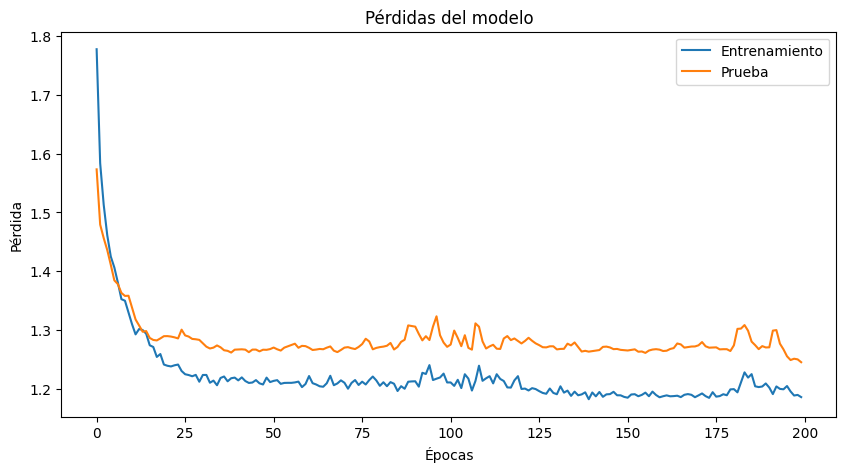

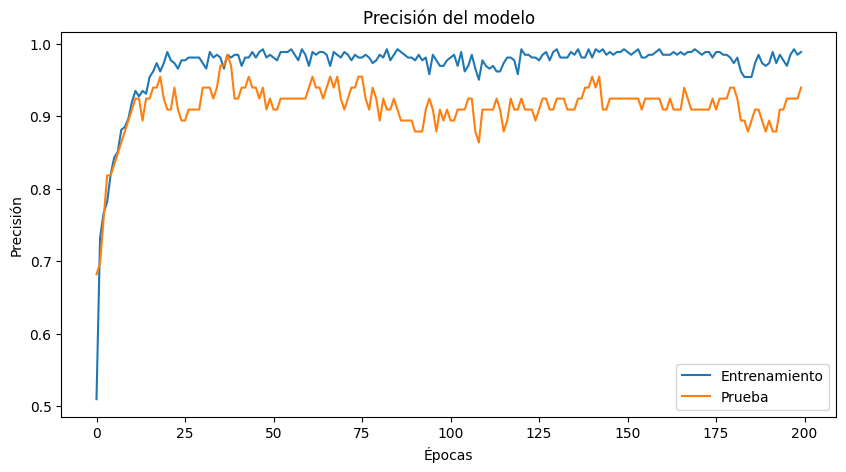

In [15]:
# Graficar pérdidas del mejor modelo
plt.figure(figsize=(10, 5))
plt.plot(best_experiment_train_losses, label='Entrenamiento')
plt.plot(best_experiment_test_losses, label='Prueba')
plt.title('Pérdidas del modelo')
plt.xlabel('Épocas')
plt.ylabel('Pérdida')
plt.legend()
plt.show()

# Graficar precisiones del mejor modelo
plt.figure(figsize=(10, 5))
plt.plot(best_experiment_train_accuracies, label='Entrenamiento')
plt.plot(best_experiment_test_accuracies, label='Prueba')
plt.title('Precisión del modelo')
plt.xlabel('Épocas')
plt.ylabel('Precisión')
plt.legend()
plt.show()




In [16]:
def visualizar_predicciones(model, X_test, y_test, paths_neutra_test, paths_expresion_test, le, device, num_muestras=66):
    model.eval()
    with torch.no_grad():
        indices = np.random.choice(len(X_test), num_muestras, replace=False)
        for idx in indices:
            data = torch.tensor(X_test[idx], dtype=torch.float32).unsqueeze(0).to(device)
            output = model(data)
            _, predicted = torch.max(output.data, 1)
            predicted_label = predicted.item()
            true_label = y_test[idx]
            # Obtener los nombres de las emociones
            predicted_emotion = le.inverse_transform([predicted_label])[0]
            true_emotion = le.inverse_transform([true_label])[0]
            # Leer las imágenes
            img_neutra = cv2.imread(paths_neutra_test[idx])
            img_expresion = cv2.imread(paths_expresion_test[idx])
            # Convertir imágenes de BGR a RGB
            img_neutra = cv2.cvtColor(img_neutra, cv2.COLOR_BGR2RGB)
            img_expresion = cv2.cvtColor(img_expresion, cv2.COLOR_BGR2RGB)
            # Mostrar las imágenes con etiquetas
            plt.figure(figsize=(8,4))
            plt.subplot(1,2,1)
            plt.imshow(img_neutra)
            plt.title('Neutra')
            plt.axis('off')
            plt.subplot(1,2,2)
            plt.imshow(img_expresion)
            plt.title(f'Expresión\nVerdadero: {true_emotion}\nPredicho: {predicted_emotion}')
            plt.axis('off')
            plt.show()


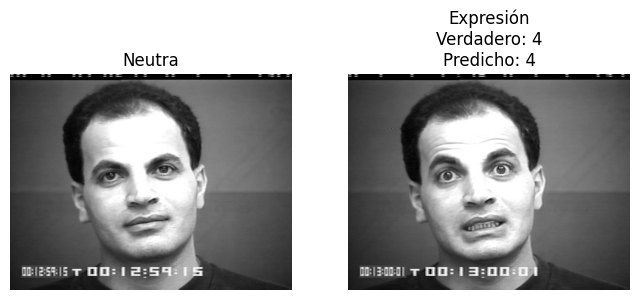

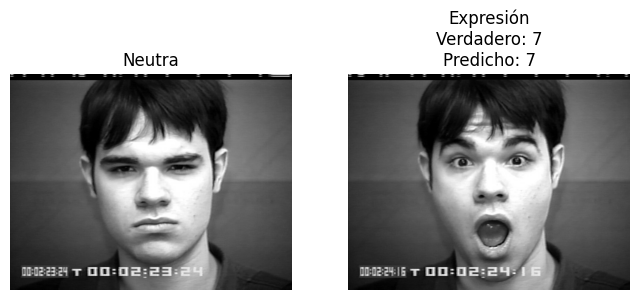

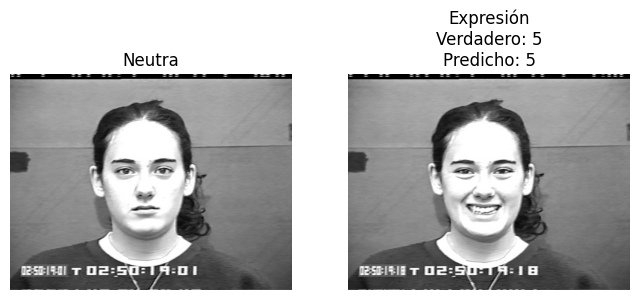

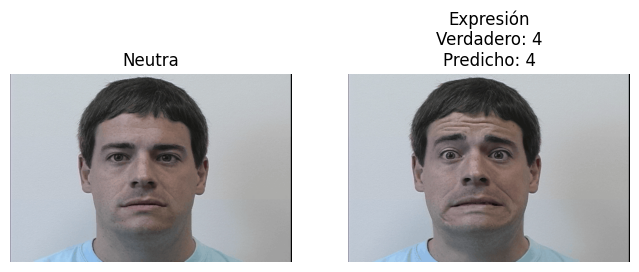

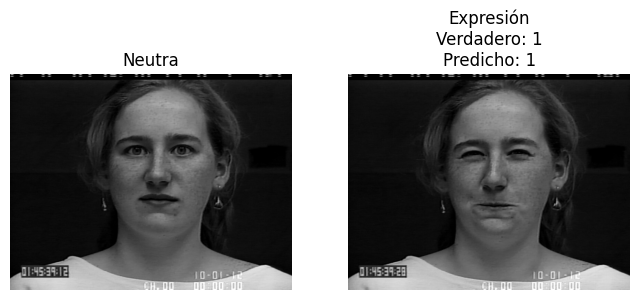

...

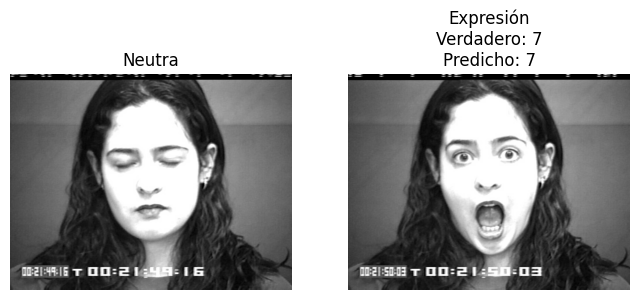

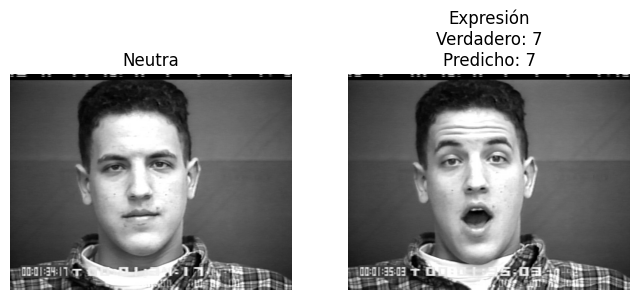

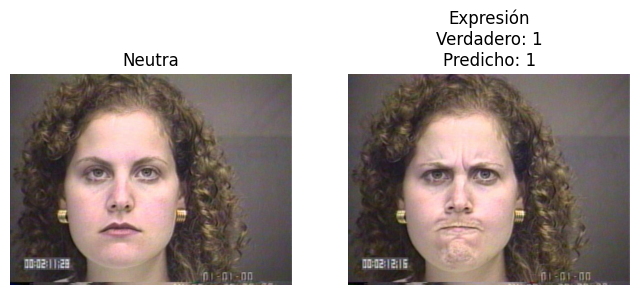

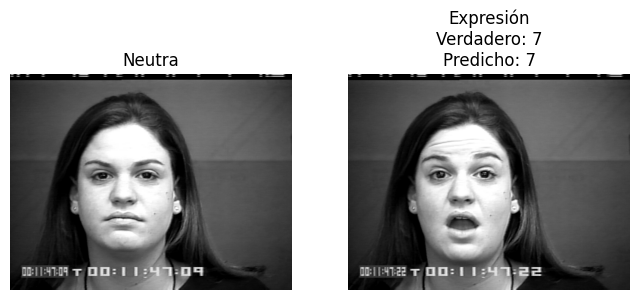

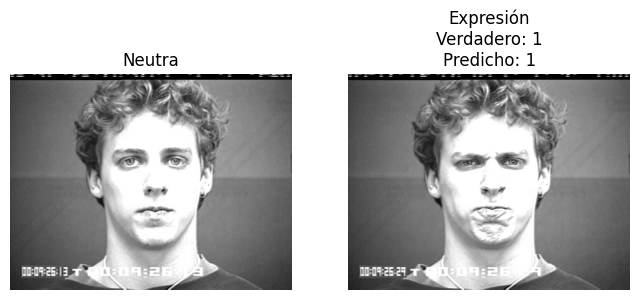

Época 200/200, Pérdida de entrenamiento: 1.1960, Precisión de entrenamiento: 0.9808, Pérdida de prueba: 1.2495, Precisión de prueba: 0.9394
Época 200/200, Pérdida de entrenamiento: 1.1960, Precisión de entrenamiento: 98.08%, Pérdida de prueba: 1.2495, Precisión de prueba: 93.94%


In [17]:
# Visualizar algunas predicciones
visualizar_predicciones(model, X_test, y_test, paths_neutra_test, paths_expresion_test, le, device, num_muestras=66)
print(f"Época {epoch+1}/{num_epochs}, Pérdida de entrenamiento: {train_loss:.4f}, Precisión de entrenamiento: {train_acc:.4f}, Pérdida de prueba: {test_loss:.4f}, Precisión de prueba: {test_acc:.4f}")
print(f"Época {epoch+1}/{num_epochs}, Pérdida de entrenamiento: {train_loss:.4f}, Precisión de entrenamiento: {train_acc*100:.2f}%, Pérdida de prueba: {test_loss:.4f}, Precisión de prueba: {test_acc*100:.2f}%")
